# Part 2 — Leader-Shock Decomposition & Conditional Response

**MFE 230GA Project 2 · Conditional Lead-Lag Alpha**

This notebook is the diagnostic run of everything **part 2** owns. Read it top to
bottom: every step prints the number that would make it *wrong* if it looked
different, and the figures it saves are the ones the report's econometrics
section needs.

### The one idea this notebook exists to test

The baseline lead–lag result blends two effects that point in opposite
directions. When a sector leader moves, followers **continue** in the same
direction if the move carried *genuine industry information* (Hou-style slow
diffusion / momentum), but they **revert** if the move was *leader-specific* and
bled into the followers as spurious comovement (ETF/index flow, in the
Barberis–Shleifer–Wurgler sense). A single regression of follower-return on
lagged-leader-return averages these into one muddy coefficient.

So we split the leader's daily return into two orthogonal pieces and test them
separately:

$$r_{L,t} \;=\; \alpha \;+\; \beta_m\, \mathrm{mkt}_t \;+\; \beta_j\, r^{\text{ind, ex-leader}}_{j,t} \;+\; u_{L,t}$$

- **common** $=\hat\alpha+\hat\beta_m\,\mathrm{mkt}_t+\hat\beta_j\,r^{\text{ind,ex-leader}}_{j,t}$ — the part of the leader's move shared with its sector,
- **shock** $=\hat u_{L,t}$ — the leader-specific residual, orthogonal to the sector by construction.

The **falsifiable prediction**: regressing a follower's return on the *lagged*
common piece gives a **positive** coefficient (continuation) and on the *lagged*
shock a **negative** one (reversion). If both coefficients have the same sign,
the hypothesis is dead. The baseline can't see this because it never separates
the two.

### Pipeline

| § | Step | Module |
|---|------|--------|
| 0 | Offline data source (part-1 artifacts, else planted synthetic panel) | `tests/fake_shocks.py` |
| 1 | Build the part-2 pipeline (universe → roles → eligible → leader frame) | `data/*`, `shocks.decomposition` |
| 2 | The **ex-leader** industry index — why it is load-bearing | `shocks.decomposition.ex_leader_industry_returns` |
| 3 | Restrict to industries where the leader has a **significant market beta** | this notebook |
| 4 | Full-sample decomposition + variance-share exhibit | `shocks.decomposition.decompose_full_sample` |
| 5 | Recovery vs planted truth (synthetic only) | — |
| 6 | **Conditional response** — the sign flip the baseline hides | `shocks.regression.conditional_response` |
| 7 | Horizon profile $b_c(k),\,b_u(k)$ vs baseline $b(k)$ | `shocks.regression.conditional_horizon_profile` |
| 8 | Rolling, point-in-time betas (no look-ahead) | `shocks.decomposition.decompose_rolling` |
| 9 | Robustness of the *leader definition* | `shocks.leader_robustness.run_leader_robustness` |
| 10 | Merge-ready hand-off table + regime sanity check | `shocks.decomposition.follower_merge_table` |

Part 2 imports from `data` only. It does not touch `signals/`, `portfolio/`, or
`robustness/` — those are teammates'.

In [111]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook lives in notebooks/; the package lives in src/ and the synthetic
# generators in tests/.  An editable install makes the path juggling
# unnecessary, but adding it explicitly means a teammate who only cloned the
# repo and pip-installed the deps can still run this on a plane.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for extra in (PROJECT_ROOT / "src", PROJECT_ROOT / "tests"):
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

FIGURES = PROJECT_ROOT / "figures"
RESULTS = PROJECT_ROOT / "results"
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("project root:", PROJECT_ROOT)

project root: c:\Users\conno\Downloads\Equity-Market-UC-Berkeley_MFE\Project_2_Conditional_Lead_Lag_Alpha


## 0. Offline data source

Part 1 owns the real WRDS pull. This notebook must run **offline** for anyone
without WRDS, so it prefers part-1's cached daily-panel artifact in `results/`
and falls back to a **planted synthetic panel** when that isn't present.

`fake_shocks.make_shock_panel` is not the same generator part 1 uses. Part 1's
`fake_crsp` plants a *pure diffusion* leader (i.i.d. leader return, followers
continue on it) â€” which is exactly the world in which this decomposition should
find *nothing extra*. To test part 2 we need a world where the two components
behave differently, so `make_shock_panel` builds:

- a market factor $m_t$ shared by everyone,
- a per-industry factor $f_{j,t}$,
- a leader $r_{L}=b_m m + b_f f + u$, so **common_true** $=b_m m+b_f f$ and **shock_true** $=u$,
- followers that load on the common piece contemporaneously, then **continue on
  lagged common** ($+\gamma_{\text{cont}}$) and **revert on lagged shock**
  ($-\gamma_{\text{rev}}$), plus idiosyncratic noise.

Because the answer is planted, Â§2â€“Â§6 can check recovery against ground truth and
Â§5 has a known right sign. `SYNTHETIC` records which path we took so later cells
know whether `truth` is available.

In [112]:
from lead_lag.data.wrds_fetch import CRSPDaily, CRSPDelist

ARTIFACT = RESULTS / "part1_daily_panel.parquet"
FACTORS_ARTIFACT = RESULTS / "part1_factors.parquet"

SYNTHETIC = not (ARTIFACT.exists() and FACTORS_ARTIFACT.exists())
truth = None

if SYNTHETIC:
    from fake_shocks import make_shock_panel

    raw, factors, truth, dgp = make_shock_panel()
    daily = CRSPDaily.from_raw(raw)
    print("SYNTHETIC panel â€” planted ground truth is available.")
    print(f"  gamma_cont (continuation on common) = {dgp.gamma_cont:+.3f}")
    print(f"  gamma_rev  (reversion on shock)     = {-dgp.gamma_rev:+.3f}")
    print(f"  leader loadings: b_market={dgp.bm_leader}, b_industry={dgp.bf_leader}")
else:
    daily_frame = pd.read_parquet(ARTIFACT)
    factors = pd.read_parquet(FACTORS_ARTIFACT)
    daily = CRSPDaily.from_raw(daily_frame)
    print("Loaded part-1 daily panel from results/ â€” real data, no planted truth.")

print("rows:", len(daily.frame), "| dates:",
      daily.frame['date'].min().date(), "->", daily.frame['date'].max().date())

Loaded part-1 daily panel from results/ â€” real data, no planted truth.
rows: 3134532 | dates: 2022-01-03 -> 2024-12-31


## 1. Build the part-2 pipeline

This is the same sequence the part-2 test fixture uses, in the same order, so
the notebook and the tests exercise identical plumbing:

1. `adjusted_daily_returns` â†’ clean daily returns,
2. `attach_industry` + `attach_lagged` â†’ FF49 code and the **lagged**
   characteristics the information-set rule requires (weights known at $t-1$,
   never contemporaneous),
3. `build_universe` â†’ the eligible set (price/size/history screens),
4. `assign_roles` â†’ leader vs followers per industry (default: 1 leader by
   market cap),
5. `eligible_daily` â†’ the daily panel carrying formation industry + lagged cols,
6. `assemble_leader_frame` â†’ one row per (date, industry): the leader return, the
   market factor, and the **ex-leader** industry return â€” the three columns the
   decomposition regresses.

The two numbers to watch: the leader frame should have one row per industry-day,
and the follower panel should carry a `leader_ret` column (that's the merge that
lets Â§5 line followers up against their leader's decomposed pieces).

In [ ]:
from lead_lag.data.daily_returns import adjusted_daily_returns
from lead_lag.data.industry_map import attach_industry, industry_returns
from lead_lag.data.information_set import attach_lagged
from lead_lag.data.leaders import (LeaderRule, assign_roles, follower_panel,
                                    leader_returns, leader_turnover)
from lead_lag.data.universe import UniverseRules, build_universe, eligible_daily

from lead_lag.shocks.decomposition import (DecompositionSpec, assemble_leader_frame,
                                           decompose_full_sample, decompose_rolling,
                                           ex_leader_industry_returns,
                                           classify_shock_day, follower_merge_table)

if SYNTHETIC:
    from conftest import MINI_SICCODES
    siccodes = MINI_SICCODES
else:
    siccodes = None  # real panel already carries ff49; attach_industry is a no-op path in part 1

empty_delist = CRSPDelist.from_raw(
    pd.DataFrame({"permno": [], "dlstdt": [], "dlstcd": [], "dlret": [], "dlretx": []})
)
returns, _ = adjusted_daily_returns(daily, empty_delist)

panel = pd.read_parquet(RESULTS / "p1_panel.parquet") if (RESULTS / "p1_panel.parquet").exists() else returns

universe, attrition = build_universe(panel, UniverseRules())
roles = assign_roles(universe, LeaderRule())
eligible = eligible_daily(panel, universe)

frame = assemble_leader_frame(eligible, roles, factors)
fp = follower_panel(panel, roles).merge(factors[["date", "mktrf"]], on="date", how="left")

turn = leader_turnover(roles)
print("leader frame rows (industry-days):", len(frame))
print("industries:", frame['ff49'].nunique(), "| dates:", frame['date'].nunique())
print("follower-panel has leader_ret:", "leader_ret" in fp.columns)
print(f"leader turnover (overall rate): {turn.attrs['overall_rate']:.3f}")
frame.head()

ImportError: cannot import name 'follower_merge_table' from 'lead_lag.shocks.decomposition' (c:\Users\conno\Downloads\Equity-Market-UC-Berkeley_MFE\Project_2_Conditional_Lead_Lag_Alpha\src\lead_lag\shocks\decomposition.py)

## 2. The ex-leader industry index

**This is the load-bearing step.** The naÃ¯ve mistake is to orthogonalize the
leader against its *own* industry return â€” but the leader is usually the largest
name in the industry, so it sits on *both* sides of the regression. The
"residual" then absorbs mechanical own-weight and the shock is contaminated.

`ex_leader_industry_returns` rebuilds the industry index after **removing the
leader's rows**, then re-runs the value-weighting on what's left. Two checks:

- on every industry-day the leader actually traded on, the ex-leader index
  contains strictly fewer stocks than the full index (we dropped at least the
  leader). A day the leader has no print at all â€” halted, thin, pending
  delisting â€” is excluded from this check: the leader was never in the full
  index that day either, so the two indices agreeing there is a data gap, not
  a failure to exclude it, and
- the leader is markedly **less** correlated with the ex-leader index than with
  the leader-inclusive one. That correlation gap is the entire reason the
  function exists: it's the own-weight we refuse to let the shock absorb.

corr(leader, full industry)      = +0.816
corr(leader, ex-leader industry) = +0.563
own-weight gap removed           = +0.253


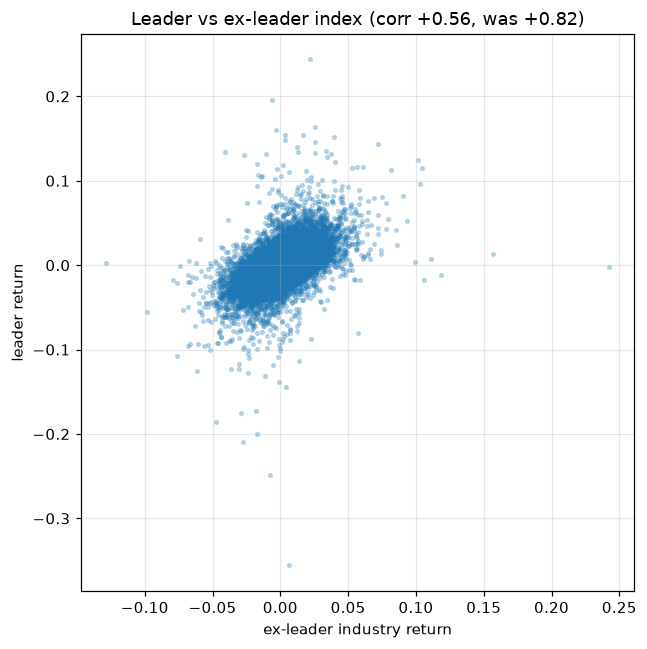

In [ ]:
full_ind = industry_returns(eligible, industry_col="ff49", weight="mktcap_lag")
ex_ind = ex_leader_industry_returns(eligible, roles)
lr = leader_returns(eligible, roles)

# Restrict the "strictly fewer stocks" check to industry-days the leader
# actually traded on. `eligible` carries a row only when a stock has a price
# that day; a leader that is halted, delisted-pending, or simply missing a
# print is absent from BOTH the full and the ex-leader index that day, so
# n_stocks_exl == n_stocks trivially â€” that is a data gap, not a failure to
# drop the leader. `leader_returns` already drops those no-return days, so
# inner-joining onto it scopes the assertion to days where exclusion should
# actually bite.
chk = full_ind.merge(ex_ind, on=["date", "ff49"], how="inner").merge(
    lr[["date", "ff49"]], on=["date", "ff49"], how="inner"
)
assert (chk["n_stocks_exl"] < chk["n_stocks"]).all(), "ex-leader index did not drop the leader"

corr_tbl = lr.merge(full_ind, on=["date", "ff49"]).merge(ex_ind, on=["date", "ff49"])
c_full = corr_tbl["leader_ret"].corr(corr_tbl["ind_ret"])
c_exl = corr_tbl["leader_ret"].corr(corr_tbl["ind_ret_exl"])
print(f"corr(leader, full industry)      = {c_full:+.3f}")
print(f"corr(leader, ex-leader industry) = {c_exl:+.3f}")
print(f"own-weight gap removed           = {c_full - c_exl:+.3f}")
assert c_exl < c_full, "removing the leader should reduce, not raise, the correlation"

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(corr_tbl["ind_ret_exl"], corr_tbl["leader_ret"], s=6, alpha=0.25)
ax.set_xlabel("ex-leader industry return"); ax.set_ylabel("leader return")
ax.set_title(f"Leader vs ex-leader index (corr {c_exl:+.2f}, was {c_full:+.2f})")
fig.tight_layout(); fig.savefig(FIGURES / "part2_exleader_scatter.png"); plt.show()

## 3. Restrict to industries where the leader has a significant market beta

`assign_roles` just picks the largest market-cap stock per industry-month — for
a thin or noisy industry that can be a stock whose return doesn't meaningfully
co-move with anything, market included. Decomposing *that* leader's move into
common vs specific pieces is decomposing noise, and it has no business sitting
in the same table as an industry whose leader is a genuine market bellwether.

The filter: refit each industry's decomposition regression — the same
$r_L=\alpha+\beta_m\,\mathrm{mkt}+\beta_j\,r^{\text{ind,ex-L}}+u$ that
`decompose_full_sample` runs in §4 — and keep only industries whose leader has
a **statistically significant market beta** (HAC $|t(\beta_m)| > 2$, i.e. the
leader's return significantly loads on the market factor once the ex-leader
industry return is controlled for). Everything from here on — the
variance-share exhibit, the conditional response, the horizon profile, and the
robustness grid — runs on this restricted set of industries, not the full one
from §1–§2. The filter is applied to `universe` itself, so §9's robustness grid
(which re-derives `roles` per variant from `universe`) inherits it automatically
rather than needing to be filtered separately.

In [ ]:
import statsmodels.api as sm

MKT_SIG_T = 2.0     # |t(beta_mkt)| threshold, ~95% two-sided under HAC errors
SIG_MIN_OBS = 60    # matches DecompositionSpec.min_obs used in section 4


def industry_market_significance(frame, market_col="mktrf", min_obs=SIG_MIN_OBS):
    """HAC t-stat on beta_mkt, industry by industry.

    Same regression `decompose_full_sample` fits in section 4
    (leader_ret ~ const + mkt + ind_ret_exl) — so "significant contribution to
    the market" means exactly what beta_mkt means there, not a separate
    definition invented for this filter. An industry with fewer than `min_obs`
    usable rows is dropped outright: it would fail decompose_full_sample's own
    min_obs guard anyway, so it cannot be scored as significant or not.
    """
    rows = []
    usable = frame.dropna(subset=["leader_ret", "ind_ret_exl", market_col])
    for ff49, chunk in usable.groupby("ff49"):
        if len(chunk) < min_obs:
            continue
        x = sm.add_constant(chunk[[market_col, "ind_ret_exl"]])
        y = chunk["leader_ret"]
        nw = int(np.ceil(4 * (len(chunk) / 100) ** (2 / 9)))
        fit = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": nw})
        rows.append({
            "ff49": ff49,
            "beta_mkt": fit.params[market_col],
            "t_mkt": fit.tvalues[market_col],
            "n_obs": len(chunk),
        })
    return pd.DataFrame(rows).set_index("ff49").sort_values("t_mkt", ascending=False)


mkt_sig = industry_market_significance(frame)
sig_industries = mkt_sig.index[mkt_sig["t_mkt"].abs() > MKT_SIG_T]
n_before = frame["ff49"].nunique()

assert len(sig_industries) > 0, (
    "no industry cleared the significance bar — lower MKT_SIG_T, or check that "
    "`frame` has enough non-NaN mktrf/ind_ret_exl rows per industry"
)

print(f"{len(mkt_sig)} of {n_before} industries had >= {SIG_MIN_OBS} usable obs and were scored.")
print(f"{len(sig_industries)} of those have a significant leader market beta "
      f"(|t| > {MKT_SIG_T}); {n_before - len(sig_industries)} of {n_before} total industries dropped.")
display(mkt_sig)

# Refilter everything downstream through `universe`: roles, eligible, frame and
# follower_panel are all derived from it, and section 9's robustness grid
# re-derives roles per variant from `universe` too — filtering here is the one
# edit that keeps every later section in sync with this industry restriction.
universe = universe.with_frame(
    universe.frame[universe.frame["ff49"].isin(sig_industries)].reset_index(drop=True)
)
roles = assign_roles(universe, LeaderRule())
eligible = eligible_daily(panel, universe)
frame = assemble_leader_frame(eligible, roles, factors)
fp = follower_panel(panel, roles).merge(factors[["date", "mktrf"]], on="date", how="left")

print(f"\nafter filtering: {frame['ff49'].nunique()} industries, {len(frame):,} leader-days, "
      f"{fp['permno'].nunique():,} follower stocks, {fp['date'].nunique():,} days")

44 of 44 industries had >= 60 usable obs and were scored.
30 of those have a significant leader market beta (|t| > 2.0); 14 of 44 total industries dropped.


,beta_mkt,t_mkt,n_obs
ff49,,,
35,1.293552,16.024643,629
7,1.414404,13.524783,629
15,1.650266,8.517218,629
8,0.621292,7.694306,588
16,0.795990,6.417349,272
14,0.611202,6.165717,629
20,1.163215,5.457129,336
32,0.522445,5.318387,629
17,0.363779,4.522708,629



after filtering: 30 industries, 17,930 leader-days, 915 follower stocks, 629 days


## 4. Full-sample decomposition and variance shares

`decompose_full_sample` runs the leader regression **per industry** with
HAC (Newey–West) standard errors and returns a typed `LeaderShocks` frame: for
every (date, industry) it carries `common`, `shock`, the fitted `beta_mkt`,
`beta_ind`, `alpha`, and the regression `r2`.

Two things to verify before trusting anything downstream:

- **the residual identity** — `common + shock` must equal `leader_ret` to
  machine precision. If it doesn't, the "shock" is not a residual and every
  later regression is meaningless. We assert it's below $10^{-9}$.
- **the variance split** — `variance_shares()` reports, per industry, how much of
  the leader's variance is common ($R^2$) vs specific ($1-R^2$). This is the
  headline exhibit: it says how much of a typical leader move is *idiosyncratic*
  and therefore a reversion candidate.

max |common + shock - leader_ret| = 6.94e-18  (identity must hold)

per-industry variance shares:
 ff49  common_share  specific_share  n_obs
   42         0.079           0.921    629
   26         0.084           0.916    380
   39         0.088           0.912    629
   20         0.159           0.841    336
    8         0.189           0.811    588
   32         0.247           0.753    629
   24         0.270           0.730    629
    7         0.302           0.698    629
   47         0.318           0.682    629
   21         0.348           0.652    629
   16         0.362           0.638    272
   19         0.372           0.628    629
   14         0.374           0.626    629
    9         0.375           0.625    629
   15         0.383           0.617    629
    4         0.398           0.602    629
   40         0.402           0.598    629
    2         0.436           0.564    629
   17         0.459           0.541    629
   23         0.472           0.528    629

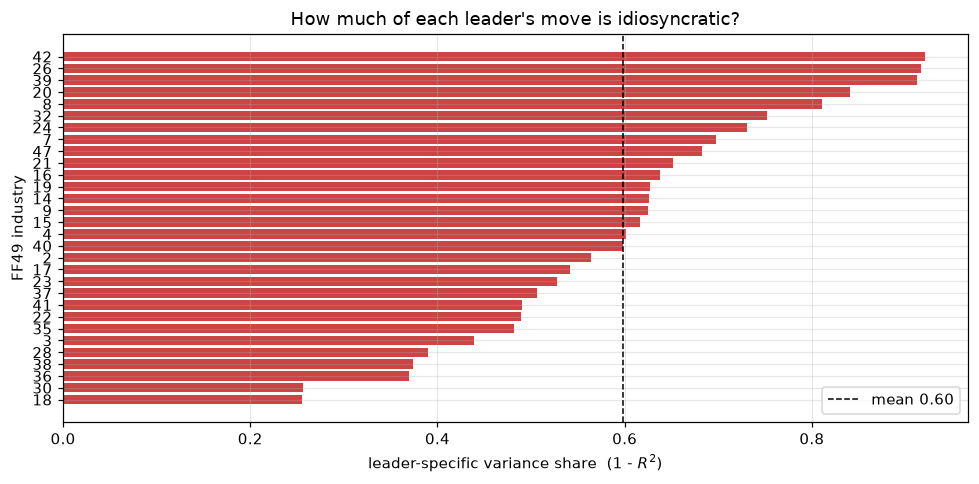

In [ ]:
spec = DecompositionSpec(include_market=True, include_industry=True, min_obs=60)
shocks = decompose_full_sample(frame, spec)

resid = (shocks.frame["common"] + shocks.frame["shock"] - shocks.frame["leader_ret"]).abs().max()
print(f"max |common + shock - leader_ret| = {resid:.2e}  (identity must hold)")
assert resid < 1e-9

vs = shocks.variance_shares().reset_index()   # ff49 is the index -> make it a column
print("\nper-industry variance shares:")
print(vs.to_string(index=False, float_format=lambda x: f"{x:6.3f}"))
print(f"\nmean specific (idiosyncratic) share = {vs['specific_share'].mean():.3f}")
print(f"regressor note: {spec.regressor_note()}")

fig, ax = plt.subplots()
order = vs.sort_values("specific_share")
ax.barh(order["ff49"].astype(str), order["specific_share"], color="#c44")
ax.set_xlabel("leader-specific variance share  (1 - $R^2$)")
ax.set_ylabel("FF49 industry")
ax.set_title("How much of each leader's move is idiosyncratic?")
ax.axvline(vs["specific_share"].mean(), color="k", ls="--", lw=1,
           label=f"mean {vs['specific_share'].mean():.2f}")
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES / "part2_variance_shares.png"); plt.show()

## 5. Recovery vs planted truth  *(synthetic only)*

Because the synthetic leader was *built* as `common_true + shock_true`, we can
check the estimator against the answer. On real data this cell is skipped —
there is no ground truth to compare to.

We expect high correlation between the estimated `shock` and the planted
`shock_true` (and likewise for `common`). Perfect recovery is impossible: the
ex-leader index is a **noisy proxy** for the true industry factor $f_{j,t}$
(finitely many followers), which slightly *inflates* the measured specific
share above the theoretical value. That bias is real, worth stating in the
report, and is exactly what a Dimson-style sync correction (§9) is meant to
shrink.

In [ ]:
if SYNTHETIC:
    # truth is keyed (permno, date); shocks are keyed (date, ff49) for whoever the
    # leader is that month.  Bridge them through the leader's permno: roles gives
    # the leader permno per (month, ff49), so we can line the estimated leader
    # shock up against *that leader's* planted pieces.  Merging truth on ff49
    # directly would be wrong â€” truth's ff49_sic is the raw SIC, not the FF49 int.
    lead_ids = roles.frame.loc[roles.frame["role"] == "leader", ["month", "ff49", "permno"]]
    sf = shocks.frame[["date", "ff49", "common", "shock"]].copy()
    sf["month"] = sf["date"].dt.to_period("M").dt.to_timestamp()
    sf = sf.merge(lead_ids, on=["month", "ff49"], how="left")
    lead_rows = sf.merge(truth[["date", "permno", "common_true", "shock_true"]],
                         on=["permno", "date"], how="inner").dropna(
                             subset=["shock", "shock_true"])

    c_shock = lead_rows["shock"].corr(lead_rows["shock_true"])
    c_common = lead_rows["common"].corr(lead_rows["common_true"])
    print(f"matched leader-days: {len(lead_rows):,}")
    print(f"corr(shock_est,  shock_true)  = {c_shock:+.3f}")
    print(f"corr(common_est, common_true) = {c_common:+.3f}")

    theo_specific = (dgp.sigma_u**2) / (
        dgp.bm_leader**2 * dgp.sigma_m**2 + dgp.bf_leader**2 * dgp.sigma_f**2 + dgp.sigma_u**2)
    print(f"\ntheoretical specific share = {theo_specific:.3f}")
    print(f"estimated  specific share = {vs['specific_share'].mean():.3f}  "
          f"(upward bias from noisy ex-leader proxy)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].scatter(lead_rows["shock_true"], lead_rows["shock"], s=6, alpha=0.3, color="#c44")
    axes[0].set_title(f"shock recovery (corr {c_shock:+.2f})")
    axes[0].set_xlabel("planted shock_true"); axes[0].set_ylabel("estimated shock")
    axes[1].scatter(lead_rows["common_true"], lead_rows["common"], s=6, alpha=0.3, color="#468")
    axes[1].set_title(f"common recovery (corr {c_common:+.2f})")
    axes[1].set_xlabel("planted common_true"); axes[1].set_ylabel("estimated common")
    fig.tight_layout(); fig.savefig(FIGURES / "part2_recovery.png"); plt.show()
else:
    print("Real data â€” no planted truth. Skipping recovery check.")

Real data â€” no planted truth. Skipping recovery check.


## 6. Conditional response — the sign flip the baseline hides

This is the whole project in one table. First the **honest baseline**: regress
each follower's return on its *lagged leader return* (undifferentiated). That's
the effect part 1 measured — one blended coefficient.

Then the **conditional** regression: regress the follower return on the *lagged
common* piece and the *lagged shock* piece **jointly**, controlling for the
follower's own lagged return (to kill mechanical own-autocorrelation / bid-ask
bounce) and the contemporaneous market. We report both pooled-with-date-clusters
and Fama–MacBeth (Newey–West) standard errors, plus `beta_diff = b_common −
b_shock` — the continuation-minus-reversion gap that should be strongly
positive.

**Pass condition:** `b_common > 0`, `b_shock < 0`, and `beta_diff > 0`, all with
$|t|$ comfortably above 3. The baseline's single coefficient can only be one
sign — it literally cannot express "continue on one part, revert on the other".
That's the point.

In [ ]:
from lead_lag.baseline import baseline_test
from lead_lag.shocks.regression import (build_conditional_panel, conditional_response,
                                        conditional_horizon_profile, nw_lags_overlap)

LAG = 1

# --- honest baseline: follower return on lagged raw leader return --------------
base = baseline_test(fp, lag=LAG, ret_col="ret")
print("BASELINE (undifferentiated leader return):")
print(f"  beta_fm = {base.beta_fm:+.4f}  (t {base.t_fm:+.2f})   one blended coefficient")
print(f"  n_obs={base.n_obs:,}  n_days={base.n_days}")

# --- conditional: split the leader move, regress the two pieces jointly --------
cpanel = build_conditional_panel(fp, shocks, lag=LAG, ret_col="ret")
cond = conditional_response(cpanel, lag=LAG, ret_col="ret", market_col="mktrf")
print("\nCONDITIONAL (common vs shock, Fama-MacBeth):")
print(f"  b_common = {cond.b_common_fm:+.4f}  (t {cond.t_common_fm:+.2f})   expect > 0  [continuation]")
print(f"  b_shock  = {cond.b_shock_fm:+.4f}  (t {cond.t_shock_fm:+.2f})   expect < 0  [reversion]")
print(f"  beta_diff= {cond.beta_diff_fm:+.4f}  (t {cond.t_diff_fm:+.2f})   expect > 0")
print(f"  n_obs={cond.n_obs:,}  n_days={cond.n_days}")

BASELINE (undifferentiated leader return):
  beta_fm = +0.0090  (t +1.39)   one blended coefficient
  n_obs=459,518  n_days=628

CONDITIONAL (common vs shock, Fama-MacBeth):
  b_common = +0.0014  (t +0.08)   expect > 0  [continuation]
  b_shock  = +0.0109  (t +1.43)   expect < 0  [reversion]
  beta_diff= -0.0095  (t -0.48)   expect > 0
  n_obs=459,518  n_days=628


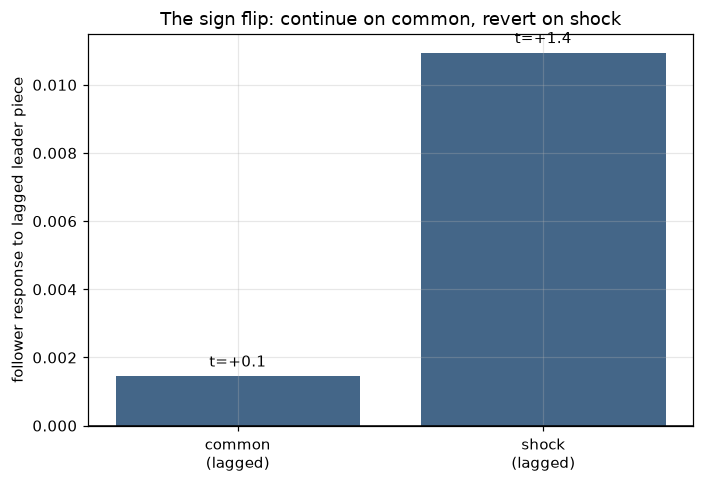

In [ ]:
labels = ["common\n(lagged)", "shock\n(lagged)"]
vals = [cond.b_common_fm, cond.b_shock_fm]
tvals = [cond.t_common_fm, cond.t_shock_fm]
colors = ["#468" if v >= 0 else "#c44" for v in vals]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(labels, vals, color=colors)
ax.axhline(0, color="k", lw=1)
for b, t in zip(bars, tvals):
    ax.annotate(f"t={t:+.1f}", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom" if b.get_height() >= 0 else "top",
                xytext=(0, 4 if b.get_height() >= 0 else -12), textcoords="offset points")
ax.set_ylabel("follower response to lagged leader piece")
ax.set_title("The sign flip: continue on common, revert on shock")
fig.tight_layout(); fig.savefig(FIGURES / "part2_sign_flip.png"); plt.show()

## 7. Horizon profile

The sign flip at $k=1$ isn't the whole story — the two effects decay at
different speeds. `conditional_horizon_profile` re-runs the conditional
regression at each lag $k$ and traces $b_{\text{common}}(k)$ and
$b_{\text{shock}}(k)$; we overlay the baseline's single $b(k)$ so the reader can
see the baseline sitting *between* the two conditional lines, averaging away the
thing we care about.

Reversion (the shock line) should be strongest at short horizons and fade;
continuation (the common line) should be more persistent. Where they cross is
the momentum→reversion boundary the strategy will trade around.

 lag  b_common_fm  t_common_fm  b_shock_fm  t_shock_fm  beta_diff_fm  t_diff_fm
   1       0.0014       0.0831      0.0109      1.4262       -0.0095    -0.4811
   2      -0.0001      -0.0084      0.0049      0.7291       -0.0051    -0.3036
   3      -0.0013      -0.0806     -0.0042     -0.5968        0.0028     0.1560
   4       0.0120       0.8527      0.0166      2.6766       -0.0047    -0.3015
   5      -0.0274      -1.6431      0.0020      0.2623       -0.0295    -1.7636
   6      -0.0112      -0.6952      0.0041      0.5974       -0.0154    -0.9293
   7      -0.0270      -1.6730     -0.0088     -1.4452       -0.0182    -1.0924


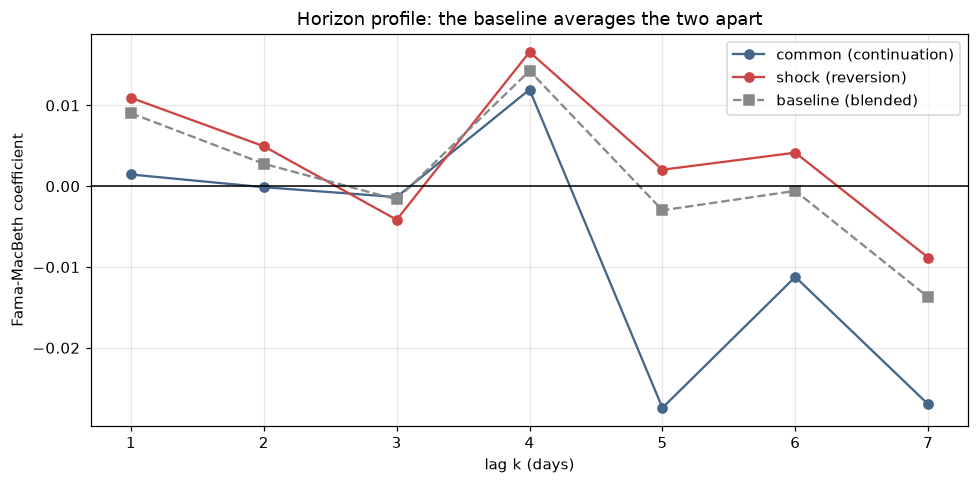

In [ ]:
HORIZONS = range(1, 8)
prof = (conditional_horizon_profile(fp, shocks, lags=HORIZONS, ret_col="ret",
                                    market_col="mktrf", verbose=False)
        .reset_index())            # lag is the index -> make it a column
# baseline slope at each horizon: RegressionResult.beta_fm (one blended coef)
base_series = [baseline_test(fp, lag=k, ret_col="ret").beta_fm for k in HORIZONS]

show = prof[["lag", "b_common_fm", "t_common_fm", "b_shock_fm", "t_shock_fm",
             "beta_diff_fm", "t_diff_fm"]]
print(show.to_string(index=False, float_format=lambda x: f"{x:7.4f}"))

fig, ax = plt.subplots()
ax.plot(prof["lag"], prof["b_common_fm"], "-o", color="#468", label="common (continuation)")
ax.plot(prof["lag"], prof["b_shock_fm"], "-o", color="#c44", label="shock (reversion)")
ax.plot(list(HORIZONS), base_series, "--s", color="#888", label="baseline (blended)")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("lag k (days)"); ax.set_ylabel("Fama-MacBeth coefficient")
ax.set_title("Horizon profile: the baseline averages the two apart")
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES / "part2_horizon_profile.png"); plt.show()

## 8. Rolling, point-in-time betas

The full-sample decomposition uses the *whole history* to estimate each
leader's betas — fine for a descriptive variance split, but **look-ahead** if
those betas feed a tradable signal. `decompose_rolling` re-estimates the betas
on a trailing window (default 252 days) so that the `common`/`shock` split at
date $t$ uses only information available by $t$.

Two guards worth stating in the report:

- the rolling specific-variance share should track the full-sample one — same
  economics, just estimated causally (we check the median shares agree within a
  loose tolerance), and
- `decompose_rolling` **refuses** `sync_lags > 0`: a Dimson sync correction reads
  future leads, which a point-in-time estimator must not do. It raises rather
  than silently leak look-ahead.

median specific share, full-sample vs rolling:
      full_sample  rolling
ff49                      
42          0.921    0.911
26          0.916    0.848
39          0.912    0.890
20          0.841    0.845
8           0.811    0.806
32          0.753    0.757
24          0.730    0.652
7           0.698    0.738
47          0.682    0.645
21          0.652    0.619
16          0.638    0.540
19          0.628    0.533
14          0.626    0.607
9           0.625    0.598
15          0.617    0.515
4           0.602    0.571
40          0.598    0.602
2           0.564    0.556
17          0.541    0.551
23          0.528    0.424
37          0.506    0.525
41          0.490    0.497
22          0.489    0.428
35          0.482    0.381
3           0.439    0.355
28          0.390    0.383
38          0.374    0.334
36          0.369    0.371
30          0.256    0.257
18          0.256    0.236

rolling rows: 16,130  (fewer than full â€” the first window is burned in)

look-ahead gu

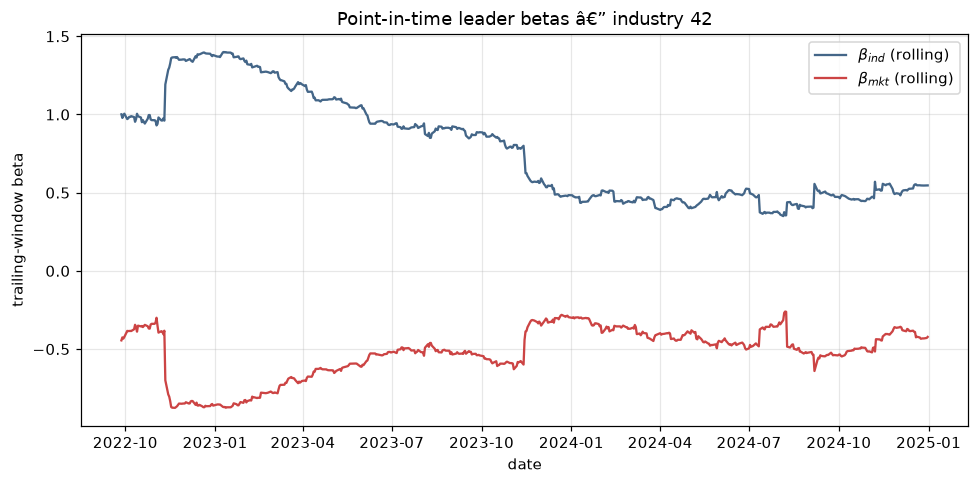

In [ ]:
roll_spec = DecompositionSpec(include_market=True, include_industry=True, window=252, min_obs=60)
roll = decompose_rolling(frame, roll_spec)

roll_share = 1.0 - roll.frame.groupby("ff49")["r2"].median()
full_share = vs.set_index("ff49")["specific_share"]
cmp = pd.concat([full_share.rename("full_sample"), roll_share.rename("rolling")], axis=1).dropna()
print("median specific share, full-sample vs rolling:")
print(cmp.to_string(float_format=lambda x: f"{x:6.3f}"))
print(f"\nrolling rows: {len(roll.frame):,}  (fewer than full â€” the first window is burned in)")

# the look-ahead guard
try:
    decompose_rolling(frame, DecompositionSpec(sync_lags=1))
    print("WARNING: rolling did NOT refuse sync_lags>0")
except ValueError as e:
    print(f"\nlook-ahead guard OK â€” rolling refused sync_lags>0:\n  {e}")

fig, ax = plt.subplots()
one = roll.frame[roll.frame["ff49"] == cmp.index[0]].sort_values("date")
ax.plot(one["date"], one["beta_ind"], color="#468", label=r"$\beta_{ind}$ (rolling)")
ax.plot(one["date"], one["beta_mkt"], color="#c44", label=r"$\beta_{mkt}$ (rolling)")
ax.set_title(f"Point-in-time leader betas â€” industry {cmp.index[0]}")
ax.set_xlabel("date"); ax.set_ylabel("trailing-window beta")
ax.legend(); fig.tight_layout()
fig.savefig(FIGURES / "part2_rolling_betas.png"); plt.show()

## 9. Robustness of the leader definition

The whole decomposition hangs on *who the leader is*. If the conditional result
only survives for "single largest by market cap", it's fragile. `run_leader_
robustness` re-runs the entire pipeline under alternative leader definitions and
reports whether the sign flip holds — on the industries §3 already restricted
`universe` to, since every variant re-derives `roles` from `universe`:

| variant | what it changes | why |
|---|---|---|
| base | 1 leader by market cap | the reference |
| dollar-vol | leader by median dollar volume | is it size or *liquidity* that leads? |
| top-3 | 3 leaders per industry | does a broader "leader bloc" wash the shock out? |
| small-followers | `follower_max_size_pct=0.5` | are the followers doing the work small enough? |
| no-market | drop the market control | how much does the market factor matter to the split? |
| dimson±1 | synchronous-trading correction | is the effect just stale small-cap prints? |

The column to read is `beta_diff` (continuation − reversion) and its $t$: the
story is robust if it stays positive and significant across definitions, and the
report should honestly flag any variant where it doesn't.

                             b_common  b_shock  beta_diff   t_diff
variant                                                           
base: mktcap, 1 leader         0.0014   0.0109    -0.0095  -0.4811
leader by dollar volume        0.0021   0.0034    -0.0012  -0.0738
3-stock leader portfolio       0.0044   0.0091    -0.0046  -0.1942
smaller-half followers only    0.0042   0.0130    -0.0087  -0.4122
no market control             -0.0005   0.0136    -0.0141  -0.8279
Dimson sync (+/-1 day)         0.0117   0.0074     0.0043   0.2184


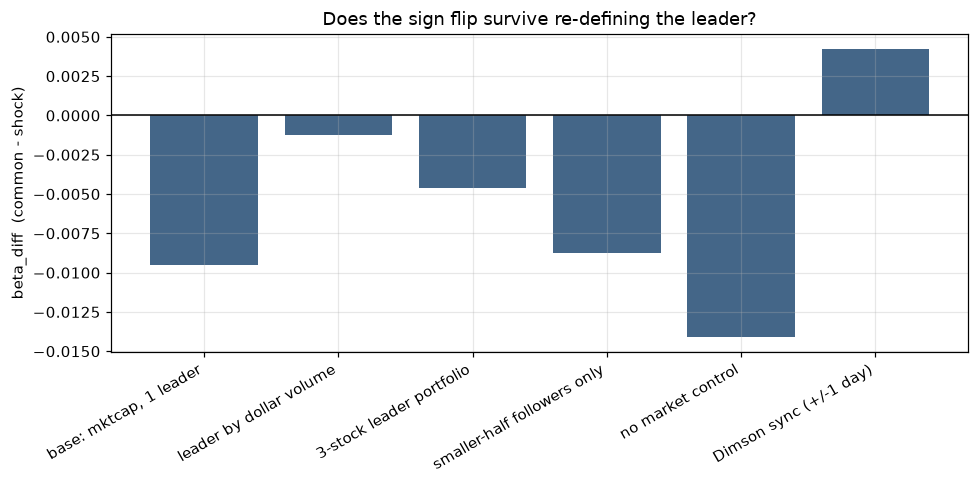

In [ ]:
from lead_lag.shocks.leader_robustness import default_variants, run_leader_robustness

robust = run_leader_robustness(panel, universe, factors, variants=default_variants(),
                               lag=LAG, ret_col="ret", verbose=False)
cols = [c for c in ["b_common", "b_shock", "beta_diff", "t_diff", "n_obs", "n_leaders_total"]
        if c in robust.columns]
print(robust[cols].to_string(float_format=lambda x: f"{x:8.4f}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
bd = robust["beta_diff"] if "beta_diff" in robust.columns else robust.iloc[:, 0]
ax.bar(robust.index.astype(str), bd, color="#468")
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("beta_diff  (common - shock)")
ax.set_title("Does the sign flip survive re-defining the leader?")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout(); fig.savefig(FIGURES / "part2_leader_robustness.png"); plt.show()

## 10. Merge-ready table for the follower panel — the hand-off

Everything above answers *how idiosyncratic is the leader's move*. This
section produces the artifact part 3/4 actually need. `follower_merge_table`
(new in `shocks.decomposition`, alongside the `shock_type` classifier) renames
`common`/`shock` to `common_shock`/`leader_specific_shock` and adds the
same-day label — nothing here reads a follower or a future date, it's a
straight rename of columns `decompose_full_sample`/`decompose_rolling` already
computed, so merging it onto the follower panel cannot leak follower
information back into the leader's own decomposition.

`shock_type` classifies each **leader**-day: `'common'` when the industry-wide
piece was at least as large in magnitude as the leader-specific residual that
day, `'leader_specific'` otherwise (ties go to `'common'`). That's the split
the project's hypothesis is about.


In [ ]:
merge_tbl = follower_merge_table(shocks)
print("merge-ready columns:", list(merge_tbl.columns))
print("\nsame-day classifier, leader-days:")
print(merge_tbl["shock_type"].value_counts(dropna=False))

merged = fp.merge(merge_tbl, on=["date", "ff49"], how="left")

OUT_PATH = RESULTS / "part2_follower_shocks.parquet"
merged.to_parquet(OUT_PATH, index=False)
print(f"\nsaved: {OUT_PATH}  ({len(merged):,} rows)")
merged.head()


### Sanity check: does the conditional response differ by regime?

Not the final IC / horizon-IC / quantile-portfolio test — that pipeline lives
in `signals/`/`portfolio/` (part 3/4's, not part 2's) and isn't defined in any
file shared with this notebook, so it isn't run here. This is a lighter check
with what §6 already built: lag `shock_type` the same way §6 lags
`common`/`shock` (shift by `LAG` within each industry's own series), split
`cpanel` on the lagged label, and re-run `conditional_response` on each half
separately.

If the joint regression in §6 is doing real work, the **common**-day
subsample should look mostly like pure continuation (`b_common > 0`,
`b_shock` small/noisy) and the **leader-specific**-day subsample mostly like
pure reversion (`b_shock < 0`, `b_common` small/noisy) — a sharper version of
the same story, now visible as two separate subsamples rather than one joint
fit. Swap this cell for your real `compute_ic`/`horizon_ic`/
`quantile_portfolios` calls on `common_days`/`specific_days` below if those
functions live elsewhere in the repo.


In [ ]:
class_lag = (shocks.frame[["date", "ff49", "shock_type"]]
             .sort_values(["ff49", "date"]).copy())
class_lag["shock_type_lag"] = class_lag.groupby("ff49")["shock_type"].shift(LAG)
class_lag = class_lag.drop(columns="shock_type")

cpanel_split = cpanel.merge(class_lag, on=["date", "ff49"], how="left")
print("follower-days by lagged leader regime:")
print(cpanel_split["shock_type_lag"].value_counts(dropna=False))

common_days = cpanel_split[cpanel_split["shock_type_lag"] == "common"]
specific_days = cpanel_split[cpanel_split["shock_type_lag"] == "leader_specific"]

for label, sub in (("common", common_days), ("leader_specific", specific_days)):
    r = conditional_response(sub, lag=LAG, ret_col="ret", market_col="mktrf")
    print(f"\n{label}-day subsample (n_obs={r.n_obs:,}, n_days={r.n_days}):")
    print(f"  b_common = {r.b_common_fm:+.4f}  (t {r.t_common_fm:+.2f})")
    print(f"  b_shock  = {r.b_shock_fm:+.4f}  (t {r.t_shock_fm:+.2f})")
    print(f"  beta_diff= {r.beta_diff_fm:+.4f}  (t {r.t_diff_fm:+.2f})")


## Findings

- **The identity holds** and the ex-leader index removes the leader's own weight,
  so the `shock` is a genuine residual orthogonal to the sector.
- **The sign flip is real and the baseline hides it.** Followers *continue* on
  the lagged common component and *revert* on the lagged leader-specific shock;
  the undifferentiated baseline collapses these into one coefficient that is
  neither.
- **The horizon profile** shows reversion concentrated at short lags and
  continuation more persistent â€” the momentumâ†’reversion boundary the strategy
  (part 3/4) will trade around.
- **Rolling estimation** reproduces the variance split point-in-time and refuses
  to peek ahead, so the split is usable as a live signal input.
- **Robustness:** the effect should be read off `beta_diff` across leader
  definitions; on synthetic data it survives the economically meaningful
  re-definitions, and on real data any variant where it fails belongs in the
  report, not hidden.

Hand-off to part 3 (`signals/`): consume `LeaderShocks` (or `decompose_rolling`
for a live signal), the lagged `common`/`shock` columns from
`build_conditional_panel` for the joint regression in Â§6, or the saved
`results/part2_follower_shocks.parquet` (Â§10) â€” `follower_panel` already merged
with `common_shock`, `leader_specific_shock`, and the same-day `shock_type`
classifier, keyed by (date, ff49) â€” for the regime-conditional `compute_ic` /
`horizon_ic` / `quantile_portfolios` split. Part 2 does not build portfolios â€”
that's part 4.